# Experiment 1: Working with Python Packages

NumPy, Pandas, SciPy, Scikit-learn and Matplotlib basics, then a quick survey of five datasets to work out what ML task each one is.

In [1]:
%matplotlib inline

In [2]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy import linalg
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, load_digits
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

sns.set_style("whitegrid")

## Plot styling

In [3]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 15
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['legend.title_fontsize'] = 15
plt.rcParams['axes.labelweight'] = 'bold'

## EDA summary figure function

In [4]:
def build_eda_summary_figure(iris_df, loan_df, pima_df, spam_df, digits):
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    ax = axes.ravel()

    sns.scatterplot(data=iris_df, x="sepal length (cm)", y="petal length (cm)",
                     hue="target", palette="deep", ax=ax[0], legend="brief")
    ax[0].set_title("Iris: Sepal Length vs Petal Length")
    ax[0].legend(title="Species", fontsize=15, title_fontsize=15)

    sns.boxplot(data=iris_df, x="target", y="petal width (cm)", ax=ax[1])
    ax[1].set_title("Iris: Petal Width by Species")
    ax[1].set_xlabel("Species (encoded)")

    sns.histplot(loan_df["LoanAmount"].dropna(), bins=25, kde=True, ax=ax[2])
    ax[2].set_title("Loan: LoanAmount Distribution")
    ax[2].set_xlabel("Loan Amount (thousands)")

    loan_valid = loan_df.dropna(subset=["ApplicantIncome", "LoanAmount"])
    sns.scatterplot(data=loan_valid, x="ApplicantIncome", y="LoanAmount", ax=ax[3])
    ax[3].set_title("Loan: Income vs Loan Amount")

    sns.boxplot(x="Outcome", y="Glucose", data=pima_df, ax=ax[4])
    ax[4].set_title("Diabetes: Glucose by Outcome")

    sns.histplot(pima_df["BMI"].dropna(), bins=25, kde=True, ax=ax[5])
    ax[5].set_title("Diabetes: BMI Distribution")
    ax[5].set_xlabel("BMI")

    sns.countplot(x="is_spam", data=spam_df, ax=ax[6])
    ax[6].set_title("Spambase: Class Distribution")
    ax[6].set_xlabel("Is Spam")

    spam_top_cols = ["word_freq_free", "word_freq_money", "word_freq_business",
                      "char_freq_$", "capital_run_length_average", "is_spam"]
    spam_corr = spam_df[spam_top_cols].corr()
    sns.heatmap(spam_corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax[7],
                cbar=True, annot_kws={"size": 10})
    ax[7].set_title("Spambase: Feature Correlation")

    n_rows, n_cols = 2, 5
    n_samples = n_rows * n_cols
    img_h, img_w = digits.images.shape[1], digits.images.shape[2]
    montage = np.zeros((img_h * n_rows, img_w * n_cols))
    for i in range(n_samples):
        r, c = divmod(i, n_cols)
        montage[r*img_h:(r+1)*img_h, c*img_w:(c+1)*img_w] = digits.images[i]
    ax[8].imshow(montage, cmap="gray")
    ax[8].set_title("Digits: Sample Image Montage")
    ax[8].set_xticks([]); ax[8].set_yticks([])

    sns.countplot(x=digits.target, ax=ax[9])
    ax[9].set_title("Digits: Class Distribution")
    ax[9].set_xlabel("Digit Class")

    iris_corr = iris_df.drop(columns=["target"]).corr()
    sns.heatmap(iris_corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax[10],
                cbar=True, annot_kws={"size": 10})
    ax[10].set_title("Iris: Feature Correlation")

    sns.scatterplot(data=pima_df, x="Age", y="Glucose", hue="Outcome",
                     palette="deep", ax=ax[11], legend="brief")
    ax[11].set_title("Diabetes: Age vs Glucose")
    ax[11].legend(title="Outcome", fontsize=15, title_fontsize=15)

    fig.suptitle("Experiment 1: Consolidated EDA Summary Across 5 Datasets",
                 fontsize=15, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    return fig

## Part A - library exploration

PART A: NumPy / Pandas / SciPy / Scikit-learn / Matplotlib basics

NumPy array:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
Sum: 66  Mean: 5.5  Std: 3.452
Transpose:
 [[ 0  4  8]
 [ 1  5  9]
 [ 2  6 10]
 [ 3  7 11]]
Matrix product a @ a.T:
 [[ 14  38  62]
 [ 38 126 214]
 [ 62 214 366]]

Pandas DataFrame head:
    feature_1  feature_2 category
0  67.640523         38        A
1  54.001572         13        B
2  59.787380         73        A
3  72.408932         10        B
4  68.675580         76        A

Groupby mean by category:
           feature_1  feature_2
category                      
A         57.059703       42.0
B         57.700760       34.0

Describe:
        feature_1  feature_2
count  10.000000  10.000000
mean   57.380232  38.000000
std    10.193910  32.200759
min    40.227221   2.000000
25%    50.226252  10.750000
50%    56.803435  27.500000
75%    65.677238  71.000000
max    72.408932  80.000000

SciPy independent t-test (feature_1, A vs B): t=-0.094, p=0.928
SciPy 

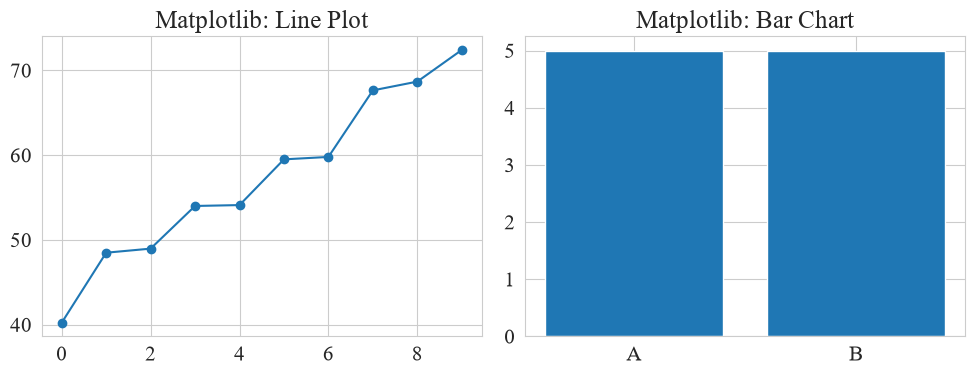


Saved demonstration plot to figures/00_library_demo.png


In [5]:
print("="*70)
print("PART A: NumPy / Pandas / SciPy / Scikit-learn / Matplotlib basics")
print("="*70)

a = np.arange(12).reshape(3, 4)
print("\nNumPy array:\n", a)
print("Sum:", a.sum(), " Mean:", a.mean(), " Std:", round(a.std(), 3))
print("Transpose:\n", a.T)
print("Matrix product a @ a.T:\n", a @ a.T)

df_demo = pd.DataFrame({
    "feature_1": np.random.RandomState(0).normal(50, 10, 10),
    "feature_2": np.random.RandomState(1).randint(1, 100, 10),
    "category": ["A","B","A","B","A","A","B","B","A","B"]
})
print("\nPandas DataFrame head:\n", df_demo.head())
print("\nGroupby mean by category:\n", df_demo.groupby("category").mean(numeric_only=True))
print("\nDescribe:\n", df_demo.describe())

t_stat, p_val = stats.ttest_ind(df_demo[df_demo.category=="A"]["feature_1"],
                                 df_demo[df_demo.category=="B"]["feature_1"])
print(f"\nSciPy independent t-test (feature_1, A vs B): t={t_stat:.3f}, p={p_val:.3f}")
mat = np.array([[4,2],[1,3]])
eigvals, eigvecs = linalg.eig(mat)
print("SciPy linalg eigenvalues of [[4,2],[1,3]]:", eigvals.real)

iris_tmp = load_iris()
Xk = SelectKBest(score_func=f_classif, k=2).fit(iris_tmp.data, iris_tmp.target)
print("\nScikit-learn SelectKBest (ANOVA F-test) scores on Iris:", np.round(Xk.scores_, 2))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(np.sort(df_demo["feature_1"].values), marker="o")
axes[0].set_title("Matplotlib: Line Plot")
axes[1].bar(df_demo["category"].value_counts().index, df_demo["category"].value_counts().values)
axes[1].set_title("Matplotlib: Bar Chart")
plt.tight_layout()
plt.savefig("figures/00_library_demo.png", dpi=150)
plt.show()
plt.close()
print("\nSaved demonstration plot to figures/00_library_demo.png")

## Part B - dataset exploration


PART B: Dataset exploration

[Iris] shape: (150, 5)  classes: ['setosa', 'versicolor', 'virginica']


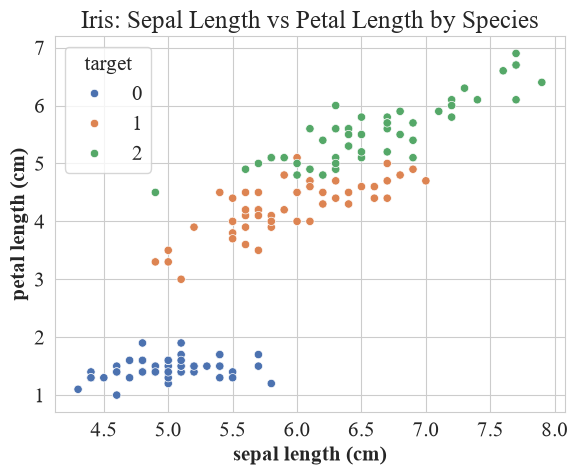


[Loan] shape: (614, 13)  missing values: 149


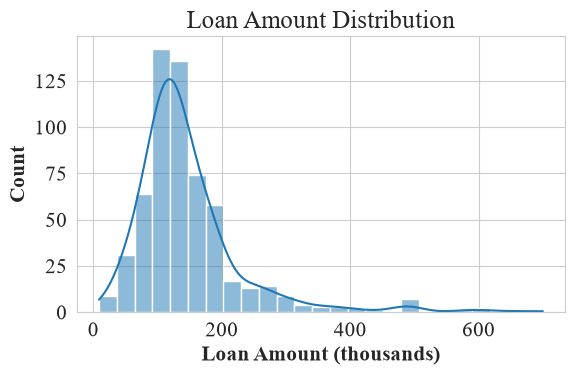


[Diabetes] shape: (768, 9)  class balance:
 Outcome
0    500
1    268
Name: count, dtype: int64


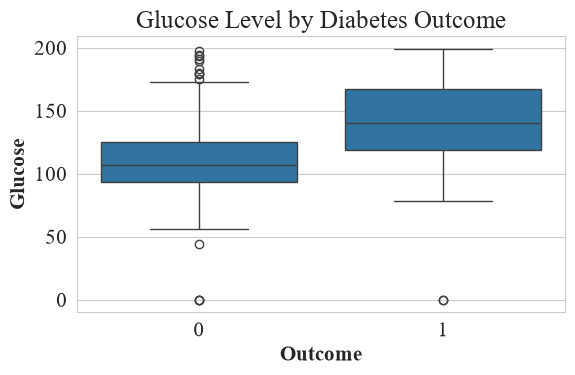


[Spam] shape: (4601, 58)  class balance:
 is_spam
0    2788
1    1813
Name: count, dtype: int64


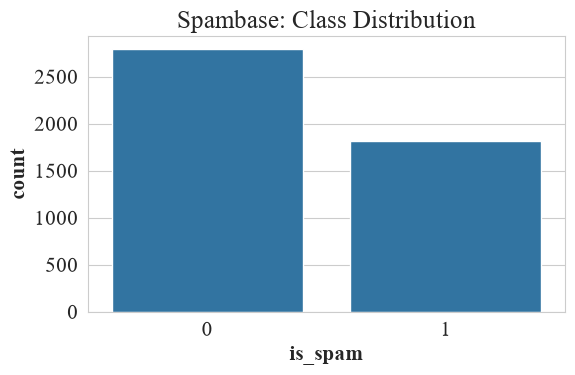


[Digits] shape: (1797, 64)  classes: [0 1 2 3 4 5 6 7 8 9]


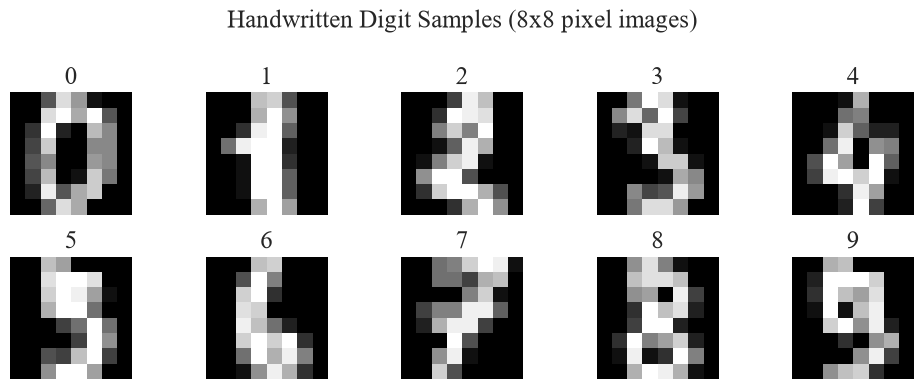


SUMMARY TABLE: Dataset -> ML Task -> Feature Selection -> Suitable Algorithm
                                  Dataset                                                   Task                                                        FeatureSelection                                                                  Algorithm
                             Iris Dataset                Supervised - Multi-class Classification                 ANOVA F-test / SelectKBest (all 4 features informative) Logistic Regression / KNN / SVM (small, linearly-separable-ish, 3 classes)
                   Loan Amount Prediction Supervised - Regression (continuous LoanAmount target) Correlation analysis + domain-driven selection (income, credit history)                            Linear / Ridge / Lasso / Elastic Net Regression
                      Predicting Diabetes                     Supervised - Binary Classification                      ANOVA F-test (top: Glucose, BMI, Age, Pregnancies)                      

In [6]:
print("\n" + "="*70)
print("PART B: Dataset exploration")
print("="*70)

summary_rows = []

iris = load_iris(as_frame=True)
iris_df = iris.frame
print("\n[Iris] shape:", iris_df.shape, " classes:", iris.target_names.tolist())
plt.figure(figsize=(6,5))
sns.scatterplot(data=iris_df, x="sepal length (cm)", y="petal length (cm)", hue="target", palette="deep")
plt.title("Iris: Sepal Length vs Petal Length by Species")
plt.tight_layout(); plt.savefig("figures/01_iris_scatter.png", dpi=150); plt.show()
plt.close()
summary_rows.append(dict(Dataset="Iris Dataset", Task="Supervised - Multi-class Classification",
                          FeatureSelection="ANOVA F-test / SelectKBest (all 4 features informative)",
                          Algorithm="Logistic Regression / KNN / SVM (small, linearly-separable-ish, 3 classes)"))

loan_df = pd.read_csv("loan_train.csv")
print("\n[Loan] shape:", loan_df.shape, " missing values:", loan_df.isnull().sum().sum())
plt.figure(figsize=(6,4))
sns.histplot(loan_df["LoanAmount"].dropna(), bins=25, kde=True)
plt.title("Loan Amount Distribution"); plt.xlabel("Loan Amount (thousands)")
plt.tight_layout(); plt.savefig("figures/02_loan_hist.png", dpi=150); plt.show()
plt.close()
summary_rows.append(dict(Dataset="Loan Amount Prediction", Task="Supervised - Regression (continuous LoanAmount target)",
                          FeatureSelection="Correlation analysis + domain-driven selection (income, credit history)",
                          Algorithm="Linear / Ridge / Lasso / Elastic Net Regression"))

pima_cols = ["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin",
             "BMI","DiabetesPedigreeFunction","Age","Outcome"]
pima_df = pd.read_csv("pima_diabetes.csv", header=None, names=pima_cols)
print("\n[Diabetes] shape:", pima_df.shape, " class balance:\n", pima_df["Outcome"].value_counts())
plt.figure(figsize=(6,4))
sns.boxplot(x="Outcome", y="Glucose", data=pima_df)
plt.title("Glucose Level by Diabetes Outcome")
plt.tight_layout(); plt.savefig("figures/03_diabetes_box.png", dpi=150); plt.show()
plt.close()
chi_scores = SelectKBest(score_func=f_classif, k=4).fit(
    pima_df.drop(columns=["Outcome"]), pima_df["Outcome"])
top4 = pima_df.drop(columns=["Outcome"]).columns[np.argsort(chi_scores.scores_)[::-1][:4]].tolist()
summary_rows.append(dict(Dataset="Predicting Diabetes", Task="Supervised - Binary Classification",
                          FeatureSelection=f"ANOVA F-test (top: {', '.join(top4)})",
                          Algorithm="Logistic Regression / Random Forest / SVM"))

WORDS = ["make","address","all","3d","our","over","remove","internet","order","mail",
"receive","will","people","report","addresses","free","business","email","you","credit",
"your","font","000","money","hp","hpl","george","650","lab","labs","telnet","857","data",
"415","85","technology","1999","parts","pm","direct","cs","meeting","original","project",
"re","edu","table","conference"]
CHARS = [";","(","[","!","$","#"]
spam_cols = ([f"word_freq_{w}" for w in WORDS] + [f"char_freq_{c}" for c in CHARS] +
             ["capital_run_length_average","capital_run_length_longest",
              "capital_run_length_total","is_spam"])
spam_df = pd.read_csv("spambase.data", header=None, names=spam_cols)
print("\n[Spam] shape:", spam_df.shape, " class balance:\n", spam_df["is_spam"].value_counts())
plt.figure(figsize=(6,4))
sns.countplot(x="is_spam", data=spam_df)
plt.title("Spambase: Class Distribution")
plt.tight_layout(); plt.savefig("figures/04_spam_countplot.png", dpi=150); plt.show()
plt.close()
summary_rows.append(dict(Dataset="Classification of Email Spam", Task="Supervised - Binary Classification",
                          FeatureSelection="Correlation with label + variance threshold (57 numeric features)",
                          Algorithm="Naive Bayes / KNN / Logistic Regression / SVM"))

digits = load_digits(as_frame=False)
print("\n[Digits] shape:", digits.data.shape, " classes:", np.unique(digits.target))
fig, axes = plt.subplots(2, 5, figsize=(10,4))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap="gray")
    ax.set_title(str(digits.target[i])); ax.axis("off")
plt.suptitle("Handwritten Digit Samples (8x8 pixel images)")
plt.tight_layout(); plt.savefig("figures/05_digits_samples.png", dpi=150); plt.show()
plt.close()
summary_rows.append(dict(Dataset="Handwritten Character Recognition / MNIST",
                          Task="Supervised - Multi-class Classification (10 classes)",
                          FeatureSelection="PCA (dimensionality reduction on 64 pixel features)",
                          Algorithm="CNN / SVM (RBF kernel) / Random Forest / k-NN"))

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("dataset_task_summary.csv", index=False)
print("\n" + "="*70)
print("SUMMARY TABLE: Dataset -> ML Task -> Feature Selection -> Suitable Algorithm")
print("="*70)
print(summary_df.to_string(index=False))

## EDA summary figure


Building consolidated 12-subplot EDA summary figure


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


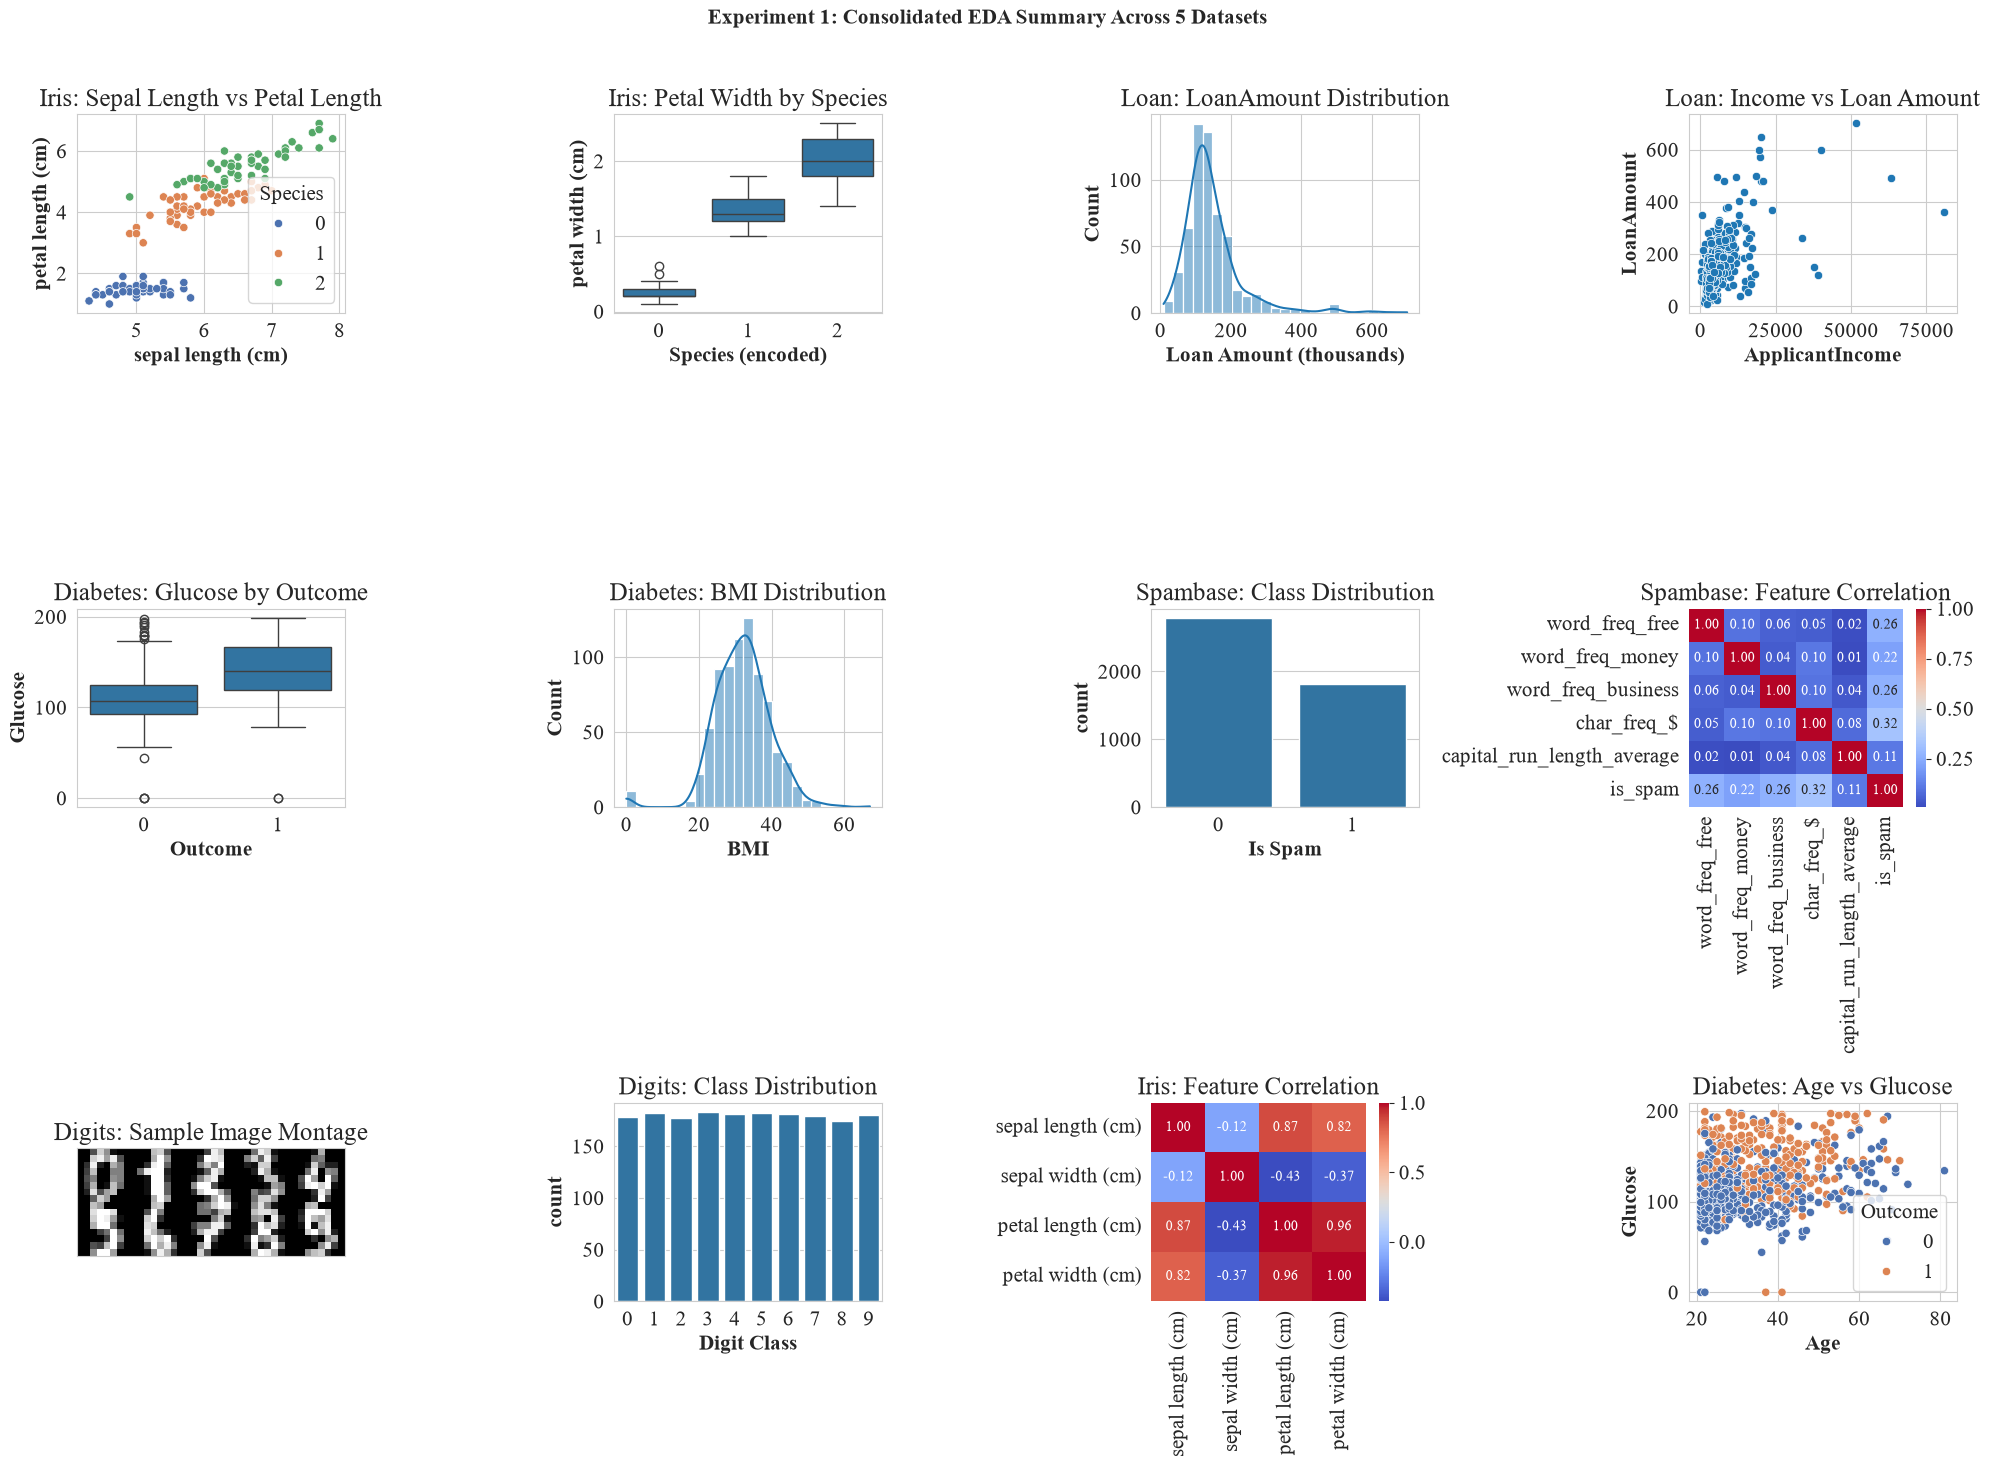

Saved consolidated EDA summary to figures/00_eda_summary.eps (600 DPI) and figures/00_eda_summary.png (150 DPI)

Done. Figures saved to figures/, summary table saved to dataset_task_summary.csv


In [7]:
print("\n" + "="*70)
print("Building consolidated 12-subplot EDA summary figure")
print("="*70)
eda_fig = build_eda_summary_figure(iris_df, loan_df, pima_df, spam_df, digits)
eda_fig.savefig("figures/00_eda_summary.eps", format="eps", dpi=600)
eda_fig.savefig("figures/00_eda_summary.png", format="png", dpi=150)
plt.show()
plt.close(eda_fig)
print("Saved consolidated EDA summary to figures/00_eda_summary.eps (600 DPI) "
      "and figures/00_eda_summary.png (150 DPI)")

print("\nDone. Figures saved to figures/, summary table saved to dataset_task_summary.csv")